# 02 – Predictive modeling (Tasks 7–15)

Continues from the **same `titanic.csv`** written by `01_eda.ipynb` (no second `sns.load_dataset` call).
Every preprocessing step lives inside a scikit-learn `Pipeline`, so it is fitted on the training data only.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib



from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # applies SMOTE ONLY when fitting (train fold)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# Offline fallback produced by 01_eda.ipynb (the raw dataset is NOT re-downloaded here)
df = pd.read_csv("titanic.csv")
print(df.shape)

(891, 15)


## Task 7 – Stratified train/test split (before any preprocessing)

In [3]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
# Not used: alive (= survived), class/embark_town (duplicates), who/adult_male/alone (derived), deck (77 % missing)
X = df[features]
y = df["survived"]

print("Class balance (whole data):")
print(y.value_counts(normalize=True).round(3).rename({0: "did not survive", 1: "survived"}).to_string())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("\nTrain:", X_train.shape, " Test:", X_test.shape)
print("Train survived share:", round(y_train.mean(), 3), "| Test survived share:", round(y_test.mean(), 3))

Class balance (whole data):
survived
did not survive    0.616
survived           0.384

Train: (712, 7)  Test: (179, 7)
Train survived share: 0.383 | Test survived share: 0.385


**Why stratify?** The target is moderately imbalanced: 61.6 % did not survive and 38.4 % survived. A plain random split could put noticeably more or fewer survivors in the test set by chance, which would make metrics unstable and not comparable. With `stratify=y`, the train (38.3 %) and test (38.5 %) sets keep the same class proportions as the full data. The split is done **before** any preprocessing so nothing from the test set influences the fitted transformers.

## Task 8 – Preprocessing (fit on training data only, via Pipeline + ColumnTransformer)

In [4]:
def make_preprocessor(num_features, cat_features, drop=None):
    numeric = Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())])
    categorical = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore", drop=drop))])
    return ColumnTransformer([("num", numeric, num_features),
                              ("cat", categorical, cat_features)],
                             verbose_feature_names_out=False)

NUM = ["pclass", "age", "sibsp", "parch", "fare"]
CAT = ["sex", "embarked"]

**Strategy.** Numeric columns (`pclass`, `age`, `sibsp`, `parch`, `fare`): median imputation then `StandardScaler`. Categorical columns (`sex`, `embarked`): most-frequent imputation then one-hot encoding (`handle_unknown='ignore'`). Everything is inside a `ColumnTransformer` wrapped in a `Pipeline` with the estimator, so calling `fit(X_train, y_train)` learns medians, modes, category lists, means and stds from the training data only, and `predict(X_test)` only applies `transform`. Nothing is ever fitted or refitted on the test data or the full pre-split dataset.

## Task 9 – Train the three classifiers on the identical split

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}
fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", make_preprocessor(NUM, CAT)), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"trained: {name}")

trained: Logistic Regression
trained: Decision Tree
trained: Random Forest


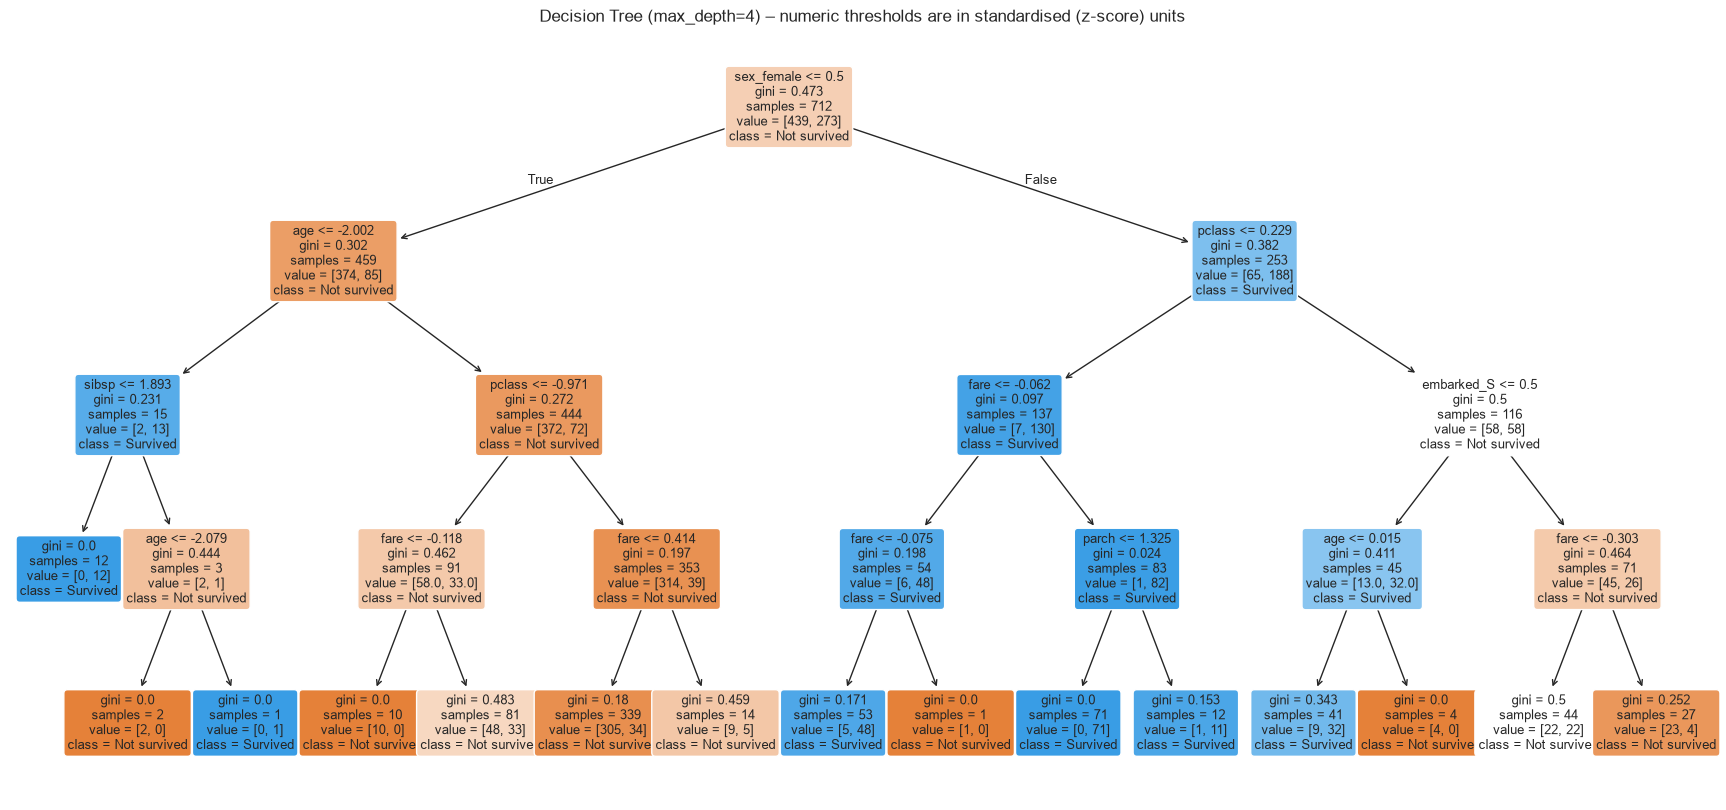

In [6]:
dt = fitted["Decision Tree"]
feature_names = dt.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(dt.named_steps["clf"], feature_names=feature_names,
          class_names=["Not survived", "Survived"], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth=4) – numeric thresholds are in standardised (z-score) units")
plt.savefig("charts/09_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 10 – Evaluate all three models

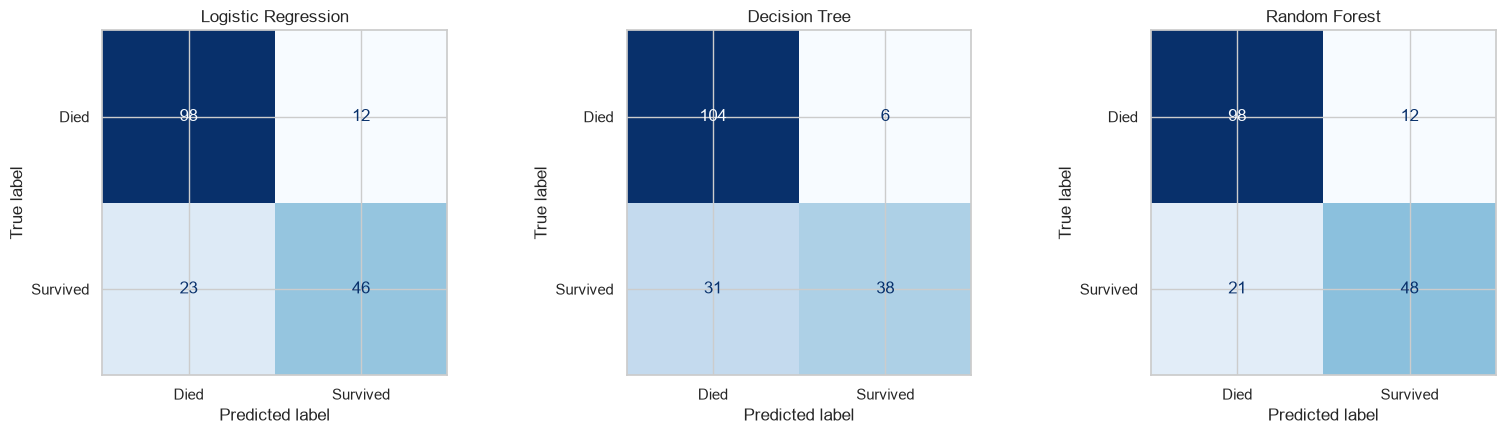

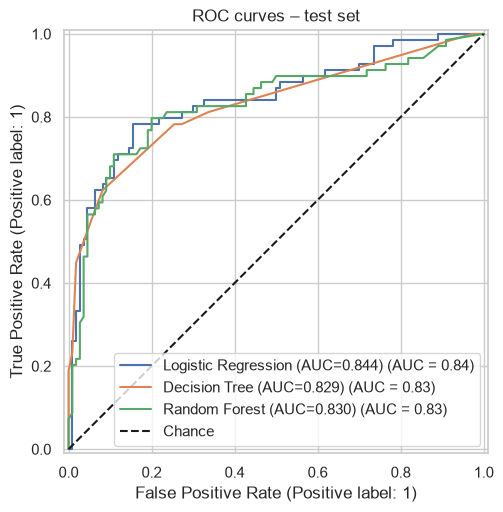

Side-by-side comparison (test set):


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.804,0.793,0.667,0.724,0.844
Decision Tree,0.793,0.864,0.551,0.673,0.829
Random Forest,0.816,0.800,0.696,0.744,0.830


In [7]:
def evaluate(pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    return {"Accuracy": accuracy_score(y_te, y_pred), "Precision": precision_score(y_te, y_pred),
            "Recall": recall_score(y_te, y_pred), "F1": f1_score(y_te, y_pred),
            "AUC": roc_auc_score(y_te, y_prob)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pipe) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, display_labels=["Died", "Survived"],
                                          cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("charts/10_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax,
                                   name=f"{name} (AUC={roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1]):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_title("ROC curves – test set"); ax.legend(loc="lower right")
plt.savefig("charts/11_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

clf_metrics = pd.DataFrame({name: evaluate(p, X_test, y_test) for name, p in fitted.items()}).T.round(3)
print("Side-by-side comparison (test set):")
clf_metrics

## Task 11 – Imbalance handling: baseline vs `class_weight='balanced'` vs SMOTE

In [8]:
print("Full data  :", y.value_counts().rename({0: "not survived", 1: "survived"}).to_dict())
print("Train split:", y_train.value_counts().rename({0: "not survived", 1: "survived"}).to_dict())

lr = lambda **kw: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kw)
variants = {
    "(a) Baseline":                Pipeline([("prep", make_preprocessor(NUM, CAT)), ("clf", lr())]),
    "(b) class_weight='balanced'": Pipeline([("prep", make_preprocessor(NUM, CAT)), ("clf", lr(class_weight="balanced"))]),
    # SMOTE sits AFTER preprocessing and INSIDE an imblearn pipeline -> only applied to the training fold in fit()
    "(c) SMOTE (train only)":      ImbPipeline([("prep", make_preprocessor(NUM, CAT)),
                                                ("smote", SMOTE(random_state=RANDOM_STATE)),
                                                ("clf", lr())]),
}
rows = {}
for name, pipe in variants.items():
    pipe.fit(X_train, y_train)
    rows[name] = evaluate(pipe, X_test, y_test)
imbalance_table = pd.DataFrame(rows).T.round(3)
imbalance_table

Full data  : {'not survived': 549, 'survived': 342}
Train split: {'not survived': 439, 'survived': 273}


,Accuracy,Precision,Recall,F1,AUC
(a) Baseline,0.804,0.793,0.667,0.724,0.844
(b) class_weight='balanced',0.804,0.730,0.783,0.755,0.846
(c) SMOTE (train only),0.810,0.740,0.783,0.761,0.841


**Conclusion.** The baseline has the highest precision (0.793) but the lowest recall (0.667), meaning it misses a third of the survivors. `class_weight='balanced'` raises recall to 0.783 at the cost of precision (0.730) and gives F1 = 0.755; SMOTE (applied only to the training fold inside the imblearn pipeline) gives almost the same trade-off, precision 0.740, recall 0.783, and the best F1 = 0.761. Both imbalance methods beat the baseline on F1 (+3 to +4 points) because they make the model pay more attention to the minority class. SMOTE is marginally best on F1, but the gap to `class_weight` is about one passenger on 179 test rows, so I would treat them as equal and prefer `class_weight='balanced'` for its simplicity (no synthetic data).

## Task 12 – Hyperparameter tuning of the Random Forest (GridSearchCV + OOB score)

In [9]:
rf_pipe = Pipeline([
    ("prep", make_preprocessor(NUM, CAT)),
    ("clf", RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RANDOM_STATE)),  # oob_score=True at construction
])
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth":    [3, 5, 7, None],
    "clf__max_features": ["sqrt", "log2", None],
}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best parameters :", grid.best_params_)
print("Best CV F1      :", round(grid.best_score_, 4))
print("OOB score (best RF, training data):", round(best_rf.named_steps["clf"].oob_score_, 4))

Best parameters : {'clf__max_depth': 7, 'clf__max_features': None, 'clf__n_estimators': 300}
Best CV F1      : 0.7521
OOB score (best RF, training data): 0.8357


**Result.** Best parameters: `n_estimators=300`, `max_depth=7`, `max_features=None` (all features), with a 5-fold CV F1 of 0.752 and an out-of-bag (OOB) score of 0.836 on the training data. Note that the tuned forest scores F1 = 0.714 on the test set, slightly *below* the default forest (0.744). With only 179 test passengers a difference of a few passengers moves F1 by several points, so this is noise rather than evidence that tuning hurt; tuning gains on this small dataset are small.

In [10]:
fitted["Random Forest (tuned)"] = best_rf
clf_metrics = pd.DataFrame({name: evaluate(p, X_test, y_test) for name, p in fitted.items()}).T.round(3)
clf_metrics

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.804,0.793,0.667,0.724,0.844
Decision Tree,0.793,0.864,0.551,0.673,0.829
Random Forest,0.816,0.800,0.696,0.744,0.830
Random Forest (tuned),0.799,0.789,0.652,0.714,0.840


## Task 13 – Regression side-task: predict `fare`

In [11]:
reg_features = ["survived", "pclass", "sex", "age", "sibsp", "parch", "embarked"]   # every other non-redundant column
Xr, yr = df[reg_features], df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg = Pipeline([
    ("prep", make_preprocessor(["survived", "pclass", "age", "sibsp", "parch"], ["sex", "embarked"], drop="first")),
    ("lin", LinearRegression()),
])
reg.fit(Xr_train, yr_train)
pred = reg.predict(Xr_test)

n = len(yr_test)
p = reg.named_steps["prep"].transform(Xr_test).shape[1]     # number of predictors after encoding
r2 = r2_score(yr_test, pred)
reg_metrics = {"MAE": mean_absolute_error(yr_test, pred),
               "RMSE": np.sqrt(mean_squared_error(yr_test, pred)),
               "R2": r2,
               "Adjusted R2": 1 - (1 - r2) * (n - 1) / (n - p - 1)}
reg_metrics = {k: round(float(v), 3) for k, v in reg_metrics.items()}
print(reg_metrics)

{'MAE': 20.898, 'RMSE': 30.533, 'R2': 0.398, 'Adjusted R2': 0.369}


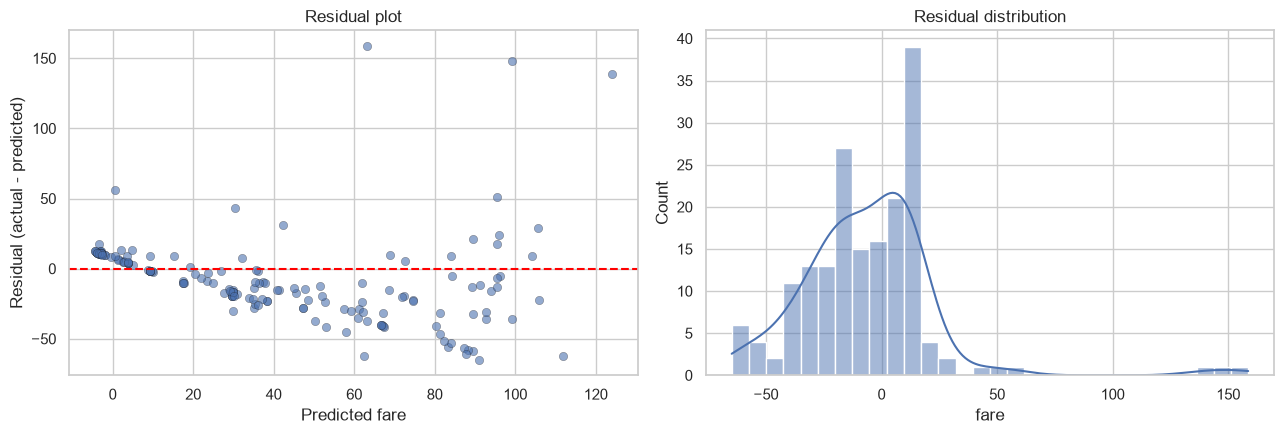

Residual std (low predicted fares) : 12.25
Residual std (high predicted fares): 38.35
corr(predicted, |residual|)        : 0.546


In [12]:
resid = yr_test - pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pred, resid, alpha=0.6, edgecolor="k", linewidth=0.3)
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicted fare"); axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residual plot")
sns.histplot(resid, bins=30, kde=True, ax=axes[1]); axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.savefig("charts/12_residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify the spread: residual std for the lower vs upper half of predictions
low = pred < np.median(pred)
print("Residual std (low predicted fares) :", round(resid[low].std(), 2))
print("Residual std (high predicted fares):", round(resid[~low].std(), 2))
print("corr(predicted, |residual|)        :", round(np.corrcoef(pred, np.abs(resid))[0, 1], 3))

**Heteroscedasticity: yes.** The linear model has MAE = 20.90, RMSE = 30.53, R² = 0.398 and Adjusted R² = 0.369, so it explains only about 40 % of the variance in fare. The residual plot is funnel-shaped: the residual std is 12.25 for the lower half of predicted fares but 38.35 for the upper half, and the correlation between predicted value and absolute residual is 0.55. The errors are therefore **not** randomly spread; they grow with the predicted fare, because fare is strongly right-skewed. A log-transform of `fare` would be a natural fix.

## Task 14 – Final model comparison table (two separate metric groups) and recommendation

In [13]:
reg_table = pd.DataFrame([reg_metrics], index=["Linear Regression (fare)"])
comparison = pd.concat({"Classification metrics": clf_metrics, "Regression metrics": reg_table}, axis=1)
comparison = comparison.fillna("—")          # classifiers have no MAE/RMSE, the regressor has no accuracy/F1
comparison

Classification metrics                          \
                                       Accuracy Precision Recall     F1   
Logistic Regression                       0.804     0.793  0.667  0.724   
Decision Tree                             0.793     0.864  0.551  0.673   
Random Forest                             0.816       0.8  0.696  0.744   
Random Forest (tuned)                     0.799     0.789  0.652  0.714   
Linear Regression (fare)                      —         —      —      —   

                                Regression metrics                             
                            AUC                MAE    RMSE     R2 Adjusted R2  
Logistic Regression       0.844                  —       —      —           —  
Decision Tree             0.829                  —       —      —           —  
Random Forest              0.83                  —       —      —           —  
Random Forest (tuned)      0.84                  —       —      —           —  
Linear Regression (fare)      —             20.898  30.533  0.398       0.369

In [14]:
# Markdown version, ready to paste into the README
flat = comparison.copy()
flat.columns = [f"{grp.split()[0]}: {m}" for grp, m in flat.columns]
print(flat.to_markdown())

|                          | Classification: Accuracy   | Classification: Precision   | Classification: Recall   | Classification: F1   | Classification: AUC   | Regression: MAE   | Regression: RMSE   | Regression: R2   | Regression: Adjusted R2   |
|:-------------------------|:---------------------------|:----------------------------|:-------------------------|:---------------------|:----------------------|:------------------|:-------------------|:-----------------|:--------------------------|
| Logistic Regression      | 0.804                      | 0.793                       | 0.667                    | 0.724                | 0.844                 | —                 | —                  | —                | —                         |
| Decision Tree            | 0.793                      | 0.864                       | 0.551                    | 0.673                | 0.829                 | —                 | —                  | —                | —                         |


**Recommendation: deploy the Random Forest (default, 200 trees).** It has the best accuracy (0.816) and the best F1 (0.744), with recall 0.696 and AUC 0.830. Logistic Regression is a close second (accuracy 0.804, F1 0.724) and actually has the highest AUC (0.844), so it is a good alternative if interpretability matters. The Decision Tree has the highest precision (0.864) but the lowest recall (0.551), so it misses almost half of the survivors, and the tuned forest did not beat the default on the test set (F1 0.714). The linear regression is a different task (predicting `fare`), so its MAE/RMSE/R² are shown in a separate metric group and are not ranked against the classifiers. Differences between the top models are small on 179 test rows.

## Task 15 – Save the complete pipeline with `joblib`

In [15]:
candidates = ["Logistic Regression", "Decision Tree", "Random Forest", "Random Forest (tuned)"]
best_name = clf_metrics.loc[candidates].sort_values(["F1", "AUC"], ascending=False).index[0]
print("Best classifier (highest F1, ties broken by AUC):", best_name)

full_pipeline = fitted[best_name]                 # preprocessing + final estimator in ONE object
joblib.dump(full_pipeline, "full_pipeline.joblib")
print(full_pipeline)

Best classifier (highest F1, ties broken by AUC): Random Forest
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                         

In [16]:
# Reload and confirm it works end-to-end on RAW, unpreprocessed data
loaded = joblib.load("full_pipeline.joblib")

raw_new = pd.DataFrame([
    {"pclass": 3, "sex": "male",   "age": 22.0,  "sibsp": 1, "parch": 0, "fare": 7.25, "embarked": "S"},
    {"pclass": 1, "sex": "female", "age": np.nan, "sibsp": 0, "parch": 0, "fare": 80.0, "embarked": np.nan},  # missing values are fine
])
print(raw_new, "\n")
print("Predictions      :", loaded.predict(raw_new))
print("P(survived)      :", loaded.predict_proba(raw_new)[:, 1].round(3))

# Reloaded pipeline must give exactly the same predictions as the in-memory one on the raw test set
assert (loaded.predict(X_test) == full_pipeline.predict(X_test)).all()
print("Reloaded pipeline reproduces the original predictions on raw X_test. Test accuracy:",
      round(accuracy_score(y_test, loaded.predict(X_test)), 3))

   pclass     sex   age  sibsp  parch   fare embarked
0       3    male  22.0      1      0   7.25        S
1       1  female   NaN      0      0  80.00      NaN 

Predictions      : [0 1]
P(survived)      : [0.14 1.  ]
Reloaded pipeline reproduces the original predictions on raw X_test. Test accuracy: 0.816
